# Cost per kg to LEO vs first flight year

White-background version of the cost-vs-launch chart from `starship_science_graphs.ipynb`.

Marks are coloured and shaped by reusability class: **single use** (black circle),
**partially reusable** (amber square), **fully reusable** (green triangle).

Only a selected few vehicles are named. The unlabelled black dots are the rest of the
fleet from the original chart — all expendable, so all drawn in the single-use style —
carried along so the named vehicles read against the wider cost cloud rather than in
isolation.

Rocket cutouts (`Saturn-V.webp`, `sls.webp`, `starship_full.png`) sit beside their
markers. They are decorative — all three are drawn to the same height on the figure,
so their relative sizes say nothing about the real vehicles.

Figures are in then-year US dollars per kg to LEO, carried over unchanged from the
original chart. The two `Starship (…)` goal points and `SLS Block I` are projections /
contracted costs rather than demonstrated market prices.

In [1]:
# --- High-resolution plot settings ---
# Bumps inline (notebook display) DPI and saved-figure DPI.
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 250       # on-screen / inline rendering
plt.rcParams['savefig.dpi'] = 250      # PNG/SVG export resolution

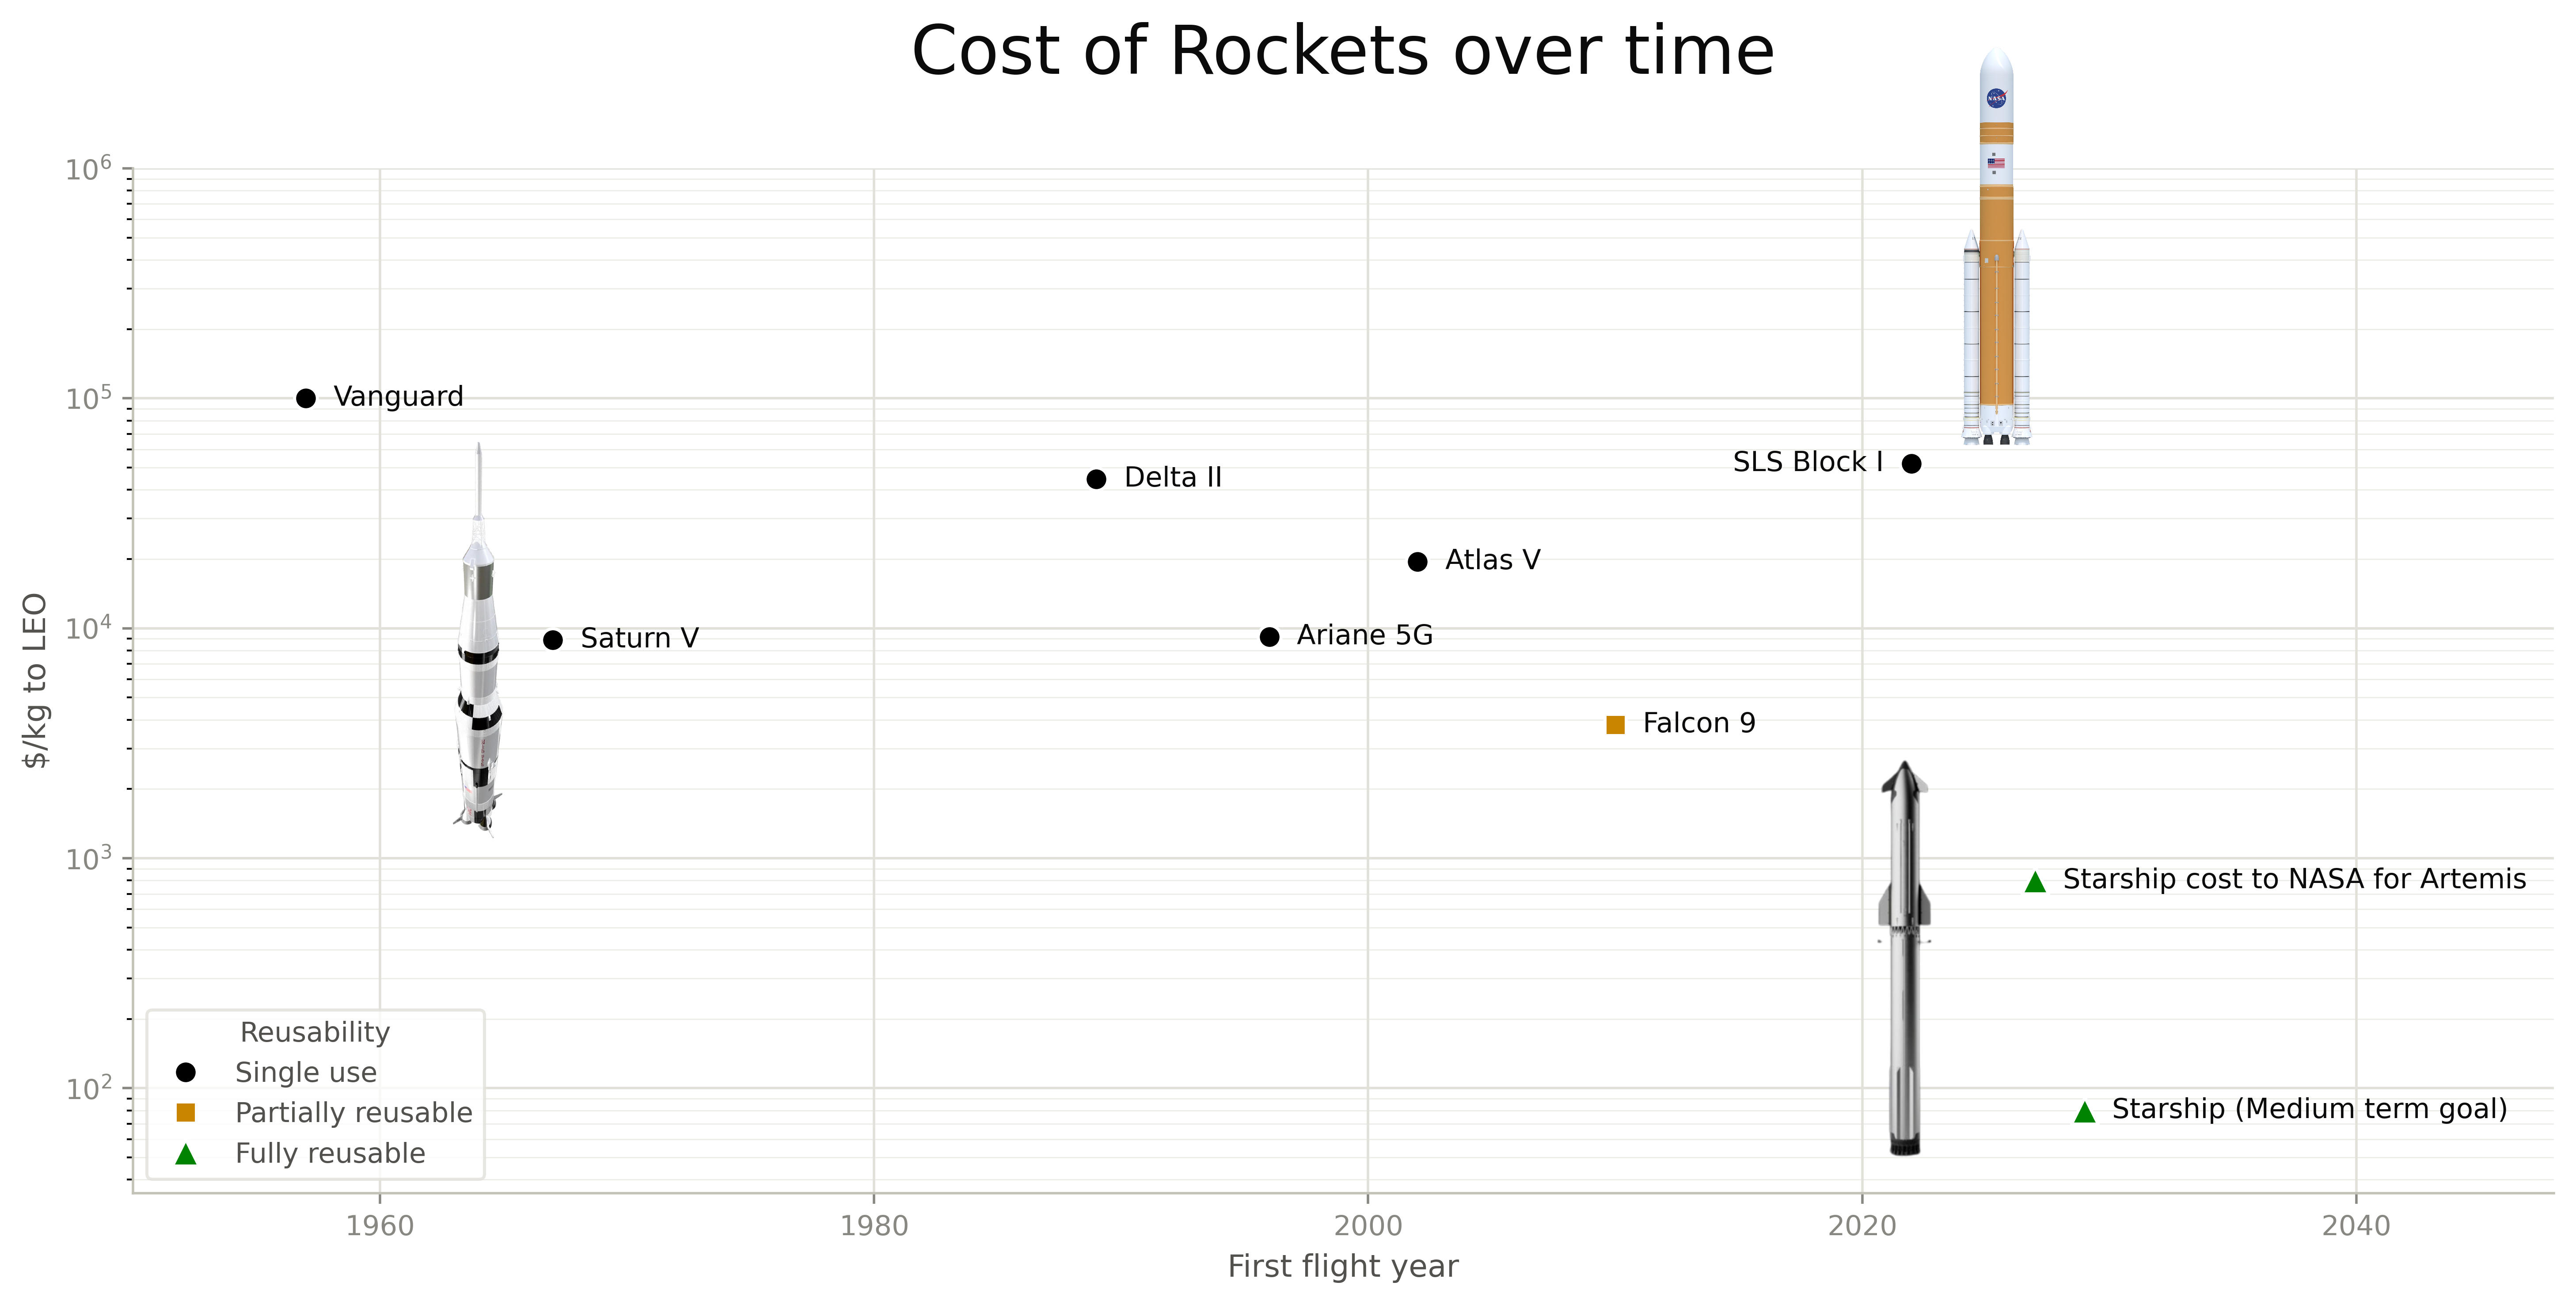

In [17]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

# --- Palette (white background) ---
BG        = '#ffffff'   # figure + axes background
INK       = '#0b0b0b'   # title, point labels
SECONDARY = '#52514e'   # axis labels
MUTED     = '#898781'   # tick labels
GRID      = '#e1e0d9'   # hairline grid
BASELINE  = '#c3c2b7'   # spines

# Reusability classes: colour + marker shape. The shape is deliberate redundancy —
# the amber/green pair sits in the CVD warning band (OKLab dE 6.9 under protanopia),
# so identity never rests on hue alone.
# Sizes are tuned per shape: matplotlib's `s` is bounding-box area, so a triangle
# needs a bigger number than a circle to look the same weight.
CLASSES = {
    'single':  ("Single use",          '#000000', 'o', 55),
    'partial': ("Partially reusable",  '#c98500', 's', 48),
    'full':    ("Fully reusable",      '#008300', '^', 75),
}

# (name, first-flight year, $/kg to LEO, label side, reusability class)
# The Starship goal points share 2028 as their notional year; edit freely.
data = [
    ("Vanguard",                          1957, 100000, 'right', 'single'),
    ("Saturn V",                          1967,   8900, 'right', 'single'),
    ("Delta II",                     1989,  44500, 'right', 'single'),
    ("Atlas V",                           2002,  19500, 'right', 'single'),
    ("Ariane 5G",      1996,  9167, 'right', 'single'),
    ("Falcon 9",       2010,   3800, 'right', 'partial'),
    ("SLS Block I",                       2022,  52100, 'left',  'single'),
    ("Starship cost to NASA for Artemis", 2027,    800, 'right', 'full'),
    ("Starship (Medium term goal)",       2029,    80, 'right', 'full'),
]

# Context: the rest of the fleet from the original chart, drawn as bare markers so the
# named vehicles above read against the wider cost cloud instead of in isolation.
# Every one of these flew expendably, so they are all "single use" and are drawn in
# exactly that class's style — they differ from the rows in `data` only in carrying no
# label. Names are kept for reference even though nothing draws them: promoting one to
# a labelled vehicle is then a copy-paste into `data` plus a label side and class.
# Proton (1965, $7,220) is deliberately omitted — it landed under the Saturn V cutout.
# (name, first-flight year, $/kg to LEO)
# context = [
#     ("Atlas SMA",      1958, 20000),
#     ("Atlas-Centaur",  1962, 29500),
#     ("Soyuz-U",        1973,  7000),
#     ("Delta 3000",     1975, 21400),
#     ("Energia",        1987, 18000),
#     ("Ariane 5G",      1996,  9167),
#     ("Long March 3B",  1996,  6200),
#     ("H-IIA",          2001, 23500),
#     ("Delta IV Heavy", 2004, 12340),
#     ("Soyuz-2",        2006,  5333),
#     ("Falcon 1",       2006, 10754),
#     ("PSLV XL",        2007, 15450),
#     ("GSLV Mk III",    2014, 25000),
#     ("Electron",       2017, 19039),
#     ("Virgin Orbit",   2020, 40000),
# ]

# --- Rocket cutouts -----------------------------------------------------------
# Decorative only: the three are drawn to a common on-figure height, NOT to a
# common physical scale. The image files live next to this notebook.
IMG_DIR = Path('.')


def load_cutout(path, rotate=0.0):
    """Open an RGBA cutout, optionally rotate it, and trim to its opaque bbox."""
    im = Image.open(path).convert('RGBA')
    if rotate:
        im = im.rotate(rotate, resample=Image.BICUBIC, expand=True)
    return np.asarray(im.crop(im.getchannel('A').getbbox()))


def add_rocket(ax, filename, xy, *, height_frac, offset, align, rotate=0.0):
    """Place a rocket cutout near a data point.

    height_frac : drawn height as a fraction of the figure height
    offset      : (dx, dy) away from the data point, in typographic points
    align       : which corner of the image lands on that offset anchor —
                  (0, 0) is bottom-left, (1, 1) is top-right
    """
    arr = load_cutout(IMG_DIR / filename, rotate)
    fig = ax.figure
    # OffsetImage draws at ny * zoom * (dpi/72) pixels, so dpi cancels out here and
    # the cutout keeps its size relative to the figure at any dpi.
    zoom = height_frac * fig.get_figheight() * 72 / arr.shape[0]
    ab = AnnotationBbox(OffsetImage(arr, zoom=zoom), xy,
                        xybox=offset, xycoords='data', boxcoords='offset points',
                        box_alignment=align, frameon=False, pad=0.0, zorder=2)
    ax.add_artist(ab)
    return ab


fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Unlabelled context markers. Styled straight off CLASSES['single'] rather than with
# repeated literals, so they cannot drift out of step with the labelled single-use
# dots — the two are meant to be indistinguishable apart from the missing label.
# _, single_colour, single_marker, single_size = CLASSES['single']
# ax.scatter([x for _, x, _ in context], [y for _, _, y in context],
#            s=single_size, color=single_colour, marker=single_marker,
#            edgecolor=BG, linewidth=1.0, zorder=3)

# One scatter call per class so each gets its own colour and marker
for key, (_, colour, marker, size) in CLASSES.items():
    xs = [x for _, x, _, _, k in data if k == key]
    ys = [y for _, _, y, _, k in data if k == key]
    ax.scatter(xs, ys, s=size, color=colour, marker=marker,
               edgecolor=BG, linewidth=1.0, zorder=3)

# Direct labels, offset off the mark so the marker position stays honest.
# Label text wears ink, not the series colour — the mark beside it carries identity.
for label, x, y, side, _ in data:
    dx = 9 if side == 'right' else -9
    ha = 'left' if side == 'right' else 'right'
    ax.annotate(label, (x, y), textcoords='offset points', xytext=(dx, 0),
                ha=ha, va='center', fontsize=9, color=INK)

ax.set_yscale('log')
# Limits are set wide enough to hold the cutouts: the x-range carries the
# right-hand Starship labels, the y-headroom carries the SLS art above its marker.
ax.set_xlim(1950, 2048)
ax.set_ylim(35, 1_000_000)

H = 0.30  # shared drawn height for all three, as a fraction of figure height
# Saturn-V.webp is shot leaning ~27 deg to the right; rotate it upright so all
# three cutouts read consistently.
add_rocket(ax, 'Saturn-V.webp',     (1967,  8900), height_frac=H, offset=(-16, 0),
           align=(1.0, 0.5), rotate=27.1)                     # left of the marker
add_rocket(ax, 'sls.webp',          (2022, 52100), height_frac=H, offset=(16, 6),
           align=(0.0, 0.0))                                  # right of and above
add_rocket(ax, 'starship_full.png', (2028,    50), height_frac=H, offset=(-58, 0),
           align=(0.1, 0.0))                                  # left of the cluster

ax.set_xlabel("First flight year", color=SECONDARY, fontsize=10)
ax.set_ylabel("$/kg to LEO", color=SECONDARY, fontsize=10)
ax.set_title("Cost of Rockets over time\n",
             color=INK, fontsize=22)

handles = [Line2D([], [], linestyle='none', marker=marker, markersize=size ** 0.5,
                  color=colour, markeredgecolor=BG, markeredgewidth=1.0, label=name)
           for name, colour, marker, size in CLASSES.values()]
legend = ax.legend(handles=handles, loc='lower left', frameon=True,
                   facecolor=BG, edgecolor=GRID, fontsize=9,
                   labelcolor=SECONDARY, title="Reusability")
legend.get_title().set_color(SECONDARY)
legend.get_title().set_fontsize(9)

ax.grid(True, which='major', color=GRID, linestyle='-', linewidth=0.8)
ax.grid(True, which='minor', color=GRID, linestyle='-', linewidth=0.4, alpha=0.6)
ax.set_axisbelow(True)
ax.tick_params(colors=MUTED, labelsize=9)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
for spine in ('left', 'bottom'):
    ax.spines[spine].set_color(BASELINE)

plt.tight_layout()
# fig.savefig('cost_per_kg_vs_year.png', facecolor=BG, bbox_inches='tight')
# fig.savefig('cost_per_kg_vs_year.svg', facecolor=BG, bbox_inches='tight')
plt.show()